<a href="https://colab.research.google.com/github/riyarvv/End-to-End-Customer-Churn-ML-Pipeline/blob/main/notebooks/16_Model_Explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# End-to-End Customer Churn ML Pipeline

## Notebook 16 - Model Explainability

### Objective

Understand which features influence customer churn and convert model outputs into business insights.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import joblib
import sys

In [4]:
project_path = "/content/drive/MyDrive/ML Projects/End-to-End-Customer-Churn-ML-Pipeline"

if project_path not in sys.path:
    sys.path.append(project_path)

from src.data_loader import load_data

In [5]:
X_train = load_data(project_path+"/data/processed/X_train.csv")

In [6]:
logistic = joblib.load(
    project_path+"/models/logistic_regression.pkl"
)

In [7]:
print(type(logistic))

<class 'sklearn.pipeline.Pipeline'>


In [8]:
print(logistic.named_steps)

{'preprocessor': ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod',
                                  'TenureGroup']),
                                ('num', StandardScaler(),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges', 'NewCustomer',
                                  'HighMonthlyCharges'])]), 'classifier': LogisticRegression(max_iter=1000)}


In [10]:
lr_model = logistic.named_steps["classifier"]

In [11]:
print(type(lr_model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [14]:
preprocessor = logistic.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))

51


In [15]:
coefficients = lr_model.coef_[0]

In [16]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefficients
})

coef_df.head()

,feature,coef
0,cat__gender_Female,-0.136479
1,cat__gender_Male,-0.161221
2,cat__Partner_No,-0.140928
3,cat__Partner_Yes,-0.156772
4,cat__Dependents_No,-0.041526


In [17]:
coef_df.sort_values(by="coef", ascending=False)

,feature,coef
32,cat__Contract_Month-to-month,0.671097
12,cat__InternetService_Fiber optic,0.610507
44,cat__TenureGroup_49-72 Months,0.419005
48,num__TotalCharges,0.298022
28,cat__StreamingTV_Yes,0.204093
31,cat__StreamingMovies_Yes,0.186136
39,cat__PaymentMethod_Electronic check,0.172479
14,cat__OnlineSecurity_No,0.156895
23,cat__TechSupport_No,0.133007
10,cat__MultipleLines_Yes,0.115294


In [20]:
coef_df.sort_values(
    by="coef",
    ascending=True
).head(10)

,feature,coef
46,num__tenure,-1.232902
34,cat__Contract_Two year,-0.837316
11,cat__InternetService_DSL,-0.630152
42,cat__TenureGroup_13-24 Months,-0.445342
47,num__MonthlyCharges,-0.412562
8,cat__MultipleLines_No,-0.311706
35,cat__PaperlessBilling_No,-0.295970
13,cat__InternetService_No,-0.278055
30,cat__StreamingMovies_No internet service,-0.278055
27,cat__StreamingTV_No internet service,-0.278055


Positive coefficients mean higher churn probability therefore those are the major churn drivers. Negative coefficients are the greatest retention factors.

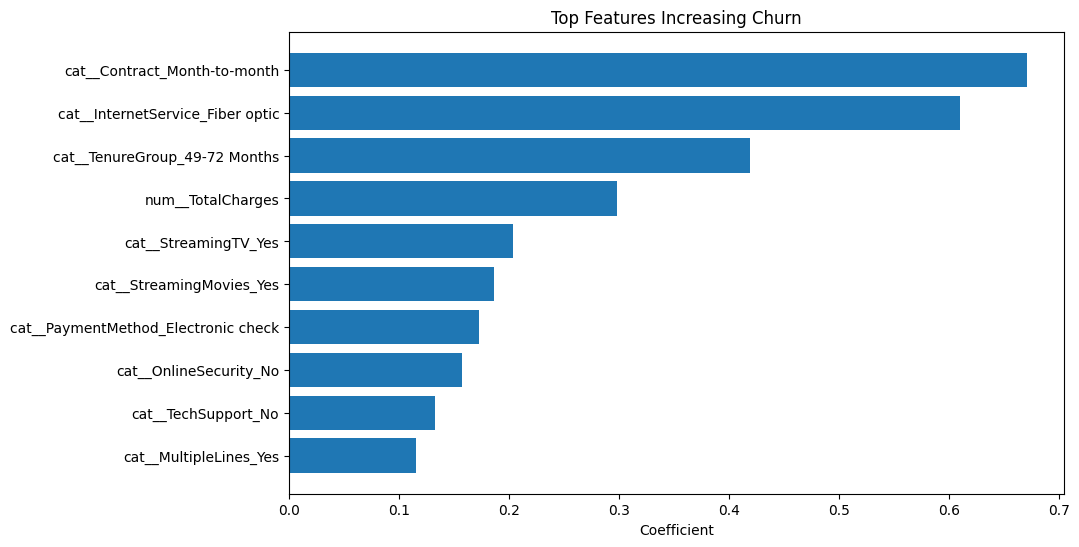

In [21]:
top_positive = coef_df.sort_values(
    by="coef",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_positive["feature"],
    top_positive["coef"]
)

plt.title("Top Features Increasing Churn")

plt.xlabel("Coefficient")

plt.gca().invert_yaxis()

plt.show()

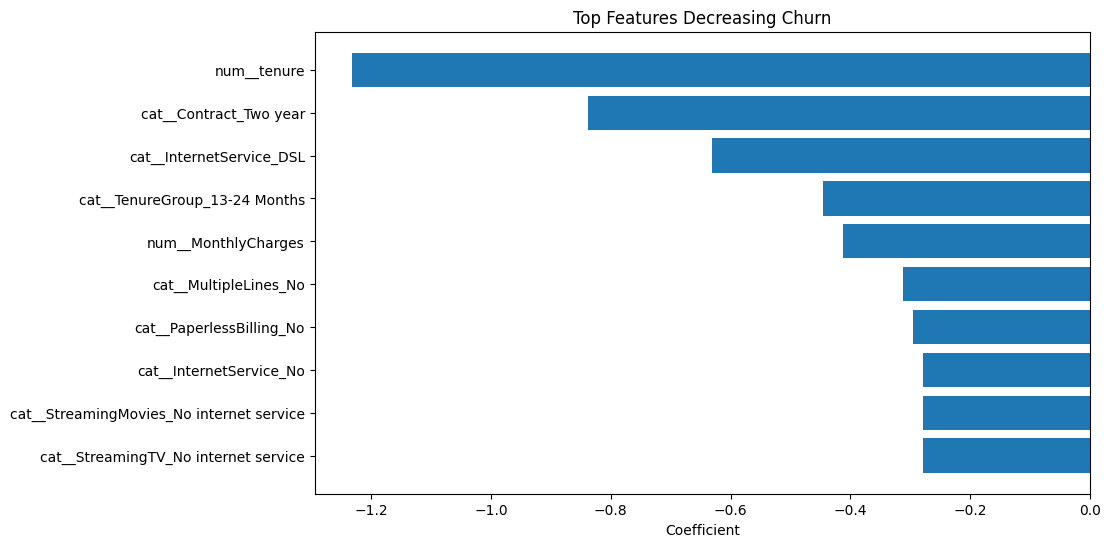

In [22]:
top_negative = coef_df.sort_values(
    by="coef",
    ascending=True
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_negative["feature"],
    top_negative["coef"]
)

plt.title("Top Features Decreasing Churn")

plt.xlabel("Coefficient")

plt.gca().invert_yaxis()

plt.show()

#### Business Recommendation  

Based on our observation of coefficients it can be seen that customers on a month-to month contract tend to churn. The company should offer incentives and promote customers to switch to more long-term plans.  

Customers using fiber optic internet service also are seen to churn more.  

Customers with high monthly charges also show increased churn risk. Personalized retention offers or flexible pricing plans may help reduce customer loss.

1. What does a positive coefficient mean in Logistic Regression?  
Positive coefficient indicates a greater probability of the customer to churn.

2. Why do businesses care about feature importance?  
Feature importance helps business make better decisions, save money, retain customers, and improve profits.

3. Which three features had the biggest impact on churn in your model?  
Month-to-month contracts, fiber optic internet service, and greater monthly tenure.